In [6]:
import math
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

def UPA(HR_img, lr_modaliry):
    USE_AMP = True
    AMP_DTYPE = torch.float16
    hr = torch.from_numpy(np.array(HR_img)).permute(2, 0, 1).unsqueeze(0).float().cuda() / 255.0  
    H,W = hr.shape[-2:]
    Hl, Wl = lr_modaliry.shape[-2:]
    scale = int(H/Hl)
    lr = F.interpolate(hr, scale_factor=1/scale, mode="bicubic", align_corners=False)

    model = LearnablePixelwiseAnisoJBU_NoParent(Hl, Wl, scale=scale).cuda()


    model.train()

    opt = torch.optim.Adam(model.parameters(), lr=1e-1)
    max_steps = 5100
    gamma = (1e-9 / 1e-1) ** (1.0 / max_steps)
    scheduler = LambdaLR(opt, lr_lambda=lambda step: gamma ** step)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    for step in range(max_steps + 1):
        opt.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
            pred = model(lr, hr)  # [1,3,512,512]
            loss = F.l1_loss(pred, hr)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            opt.step()

        scheduler.step()

        if step == 50:
            break

    model.eval()
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
        hr_feat = model(lr_modaliry, hr)
    return hr_feat

@torch.no_grad()
def _build_offsets(R_max: int, device: torch.device):
    """Return flattened neighbor offsets within square radius R_max."""
    offs = torch.arange(-R_max, R_max + 1, device=device)
    dY, dX = torch.meshgrid(offs, offs, indexing='ij')
    return dY.reshape(-1), dX.reshape(-1)  # [K], [K]


def _tanh_bound_pi(raw: torch.Tensor):
    """Map R -> (-pi, pi) smoothly."""
    return math.pi * torch.tanh(raw)


def gather_lr_scalar_general(map_lr: torch.Tensor, Ui: torch.Tensor, Vi: torch.Tensor):
    """
    map_lr: [1,1,Hl,Wl] or [Hl,Wl] or [H,W]
    Ui, Vi: [Bn, Hh, Wh] integer indices
    return: [Bn, Hh, Wh] gathered values
    """
    Hl, Wl = map_lr.shape[-2:]
    flat = Hl * Wl
    idx = (Ui * Wl + Vi).reshape(-1)
    t = map_lr.view(flat)
    vals = t.index_select(0, idx)
    return vals.view(Ui.shape[0], Ui.shape[1], Ui.shape[2])


def gs_jbu_aniso_noparent(
    feat_lr: torch.Tensor,     # [1,C,Hl,Wl], float16/float32 (cuda)
    guide_hr: torch.Tensor,    # [1,3,Hh,Wh], float32 (cuda)
    scale: int,
    sigma_x_map: torch.Tensor, # [1,1,Hl,Wl], float32
    sigma_y_map: torch.Tensor, # [1,1,Hl,Wl], float32
    theta_map: torch.Tensor,   # [1,1,Hl,Wl], float32 (radians)
    sigma_r_map: torch.Tensor, # [1,1,Hl,Wl], float32
    R_max: int = 4,
    alpha_dyn: float = 2.0,
    C_chunk: int = 512,
    Nn_chunk: int = 81,
    center_mode: str = "nearest",  # "nearest" | "floor"
    use_autocast: bool = True,
):

    _, C, Hl, Wl = feat_lr.shape
    _, _, Hh, Wh = guide_hr.shape

    dev = feat_lr.device
    dtype_feat = feat_lr.dtype
    dtype_acc = torch.float32

    # HR grid
    y = torch.arange(Hh, device=dev, dtype=torch.float32)
    x = torch.arange(Wh, device=dev, dtype=torch.float32)
    Y, X = torch.meshgrid(y, x, indexing='ij')  # [Hh,Wh]

    u = (Y + 0.5) / scale - 0.5
    v = (X + 0.5) / scale - 0.5

    if center_mode == "nearest":
        uc = torch.round(u).clamp(0, Hl - 1).to(torch.long)
        vc = torch.round(v).clamp(0, Wl - 1).to(torch.long)
    elif center_mode == "floor":
        uc = torch.floor(u).clamp(0, Hl - 1).to(torch.long)
        vc = torch.floor(v).clamp(0, Wl - 1).to(torch.long)
    else:
        raise ValueError("center_mode must be 'nearest' or 'floor'")

    # dynamic radius from (upsampled) sigma_e = max(sx,sy)
    sigma_eff = torch.maximum(sigma_x_map, sigma_y_map)  # [1,1,Hl,Wl]
    sigma_eff_hr = F.interpolate(sigma_eff, (Hh, Wh), mode='bilinear', align_corners=False)
    R_map = torch.ceil(alpha_dyn * sigma_eff_hr).clamp_(min=1, max=R_max).to(torch.int64)  # [1,1,Hh,Wh]

    dY_all, dX_all = _build_offsets(R_max, dev)
    K = dY_all.numel()

    num_s = torch.zeros(C, Hh, Wh, device=dev, dtype=dtype_acc)
    den_s = torch.zeros(   Hh, Wh, device=dev, dtype=dtype_acc)
    m     = torch.full((Hh, Wh), float("-inf"), device=dev, dtype=dtype_acc)

    guide32 = guide_hr.to(torch.float32, copy=False)
    sx_map32 = sigma_x_map.to(torch.float32, copy=False)
    sy_map32 = sigma_y_map.to(torch.float32, copy=False)
    th_map32 = theta_map.to(torch.float32, copy=False)
    sr_map32 = sigma_r_map.to(torch.float32, copy=False)

    flat = Hl * Wl
    feat_flat = feat_lr[0].permute(1, 2, 0).reshape(flat, C).contiguous()

    guide_lr = F.interpolate(guide32, size=(Hl, Wl), mode='bilinear', align_corners=False)  # [1,3,Hl,Wl]

    autocast_ctx = torch.cuda.amp.autocast(enabled=use_autocast, dtype=torch.float16)

    with autocast_ctx:
        for n0 in range(0, K, Nn_chunk):
            n1 = min(n0 + Nn_chunk, K)
            dY = dY_all[n0:n1].view(-1, 1, 1)  # [Bn,1,1]
            dX = dX_all[n0:n1].view(-1, 1, 1)
            Bn = dY.shape[0]

            Ui = torch.clamp(uc.unsqueeze(0) + dY, 0, Hl - 1)
            Vi = torch.clamp(vc.unsqueeze(0) + dX, 0, Wl - 1)

            rad2 = (dY ** 2 + dX ** 2)
            mask = (rad2 <= (R_map ** 2)).squeeze(0).squeeze(0)  # [Bn,Hh,Wh]

            cy = (Ui.to(torch.float32) + 0.5) * scale - 0.5
            cx = (Vi.to(torch.float32) + 0.5) * scale - 0.5
            dx = X.unsqueeze(0) - cx
            dy = Y.unsqueeze(0) - cy

            sx = gather_lr_scalar_general(sx_map32, Ui, Vi).clamp_min(1e-6)  # [Bn,Hh,Wh]
            sy = gather_lr_scalar_general(sy_map32, Ui, Vi).clamp_min(1e-6)
            th = gather_lr_scalar_general(th_map32, Ui, Vi)
            sr = gather_lr_scalar_general(sr_map32, Ui, Vi).clamp_min(1e-6)

            cos_t, sin_t = torch.cos(th), torch.sin(th)
            x_p = dx * cos_t + dy * sin_t
            y_p = -dx * sin_t + dy * cos_t
            log_ws = -(x_p ** 2) / (2 * sx ** 2 + 1e-8) - (y_p ** 2) / (2 * sy ** 2 + 1e-8)  # [Bn,Hh,Wh]

            g0 = gather_lr_scalar_general(guide_lr[0, 0, ...], Ui, Vi)  # [Bn,Hh,Wh]
            g1 = gather_lr_scalar_general(guide_lr[0, 1, ...], Ui, Vi)
            g2 = gather_lr_scalar_general(guide_lr[0, 2, ...], Ui, Vi)
            diff2 = (guide32[0, 0] - g0) ** 2 + (guide32[0, 1] - g1) ** 2 + (guide32[0, 2] - g2) ** 2
            log_wr = -diff2 / (2.0 * sr * sr + 1e-8)

            log_w = log_ws + log_wr
            log_w = torch.where(mask, log_w, torch.full_like(log_w, float("-inf")))

            m_chunk = torch.max(log_w, dim=0).values            # [Hh,Wh]
            valid = torch.isfinite(m_chunk)
            if not valid.any():
                continue

            m_new = m.clone()
            m_new[valid] = torch.maximum(m[valid], m_chunk[valid])

            delta = (m - m_new).clamp_max(0)
            scale_old = torch.ones_like(den_s)
            scale_old[valid] = torch.exp(delta[valid])
            den_s.mul_(scale_old)
            num_s.mul_(scale_old.unsqueeze(0))

            log_w_shift = log_w - m_new.unsqueeze(0)
            log_w_shift[:, ~valid] = float("-inf")
            s = torch.exp(log_w_shift)  # [Bn,Hh,Wh]

            den_s.add_(s.sum(0))

            idx_flat = (Ui * Wl + Vi).reshape(-1)
            for c0 in range(0, C, C_chunk):
                c1 = min(c0 + C_chunk, C)
                feat_sel = feat_flat.index_select(0, idx_flat)[:, c0:c1]  # [Bn*Hh*Wh, Cc]
                feat_sel = feat_sel.view(Bn, Hh, Wh, c1 - c0)             # [Bn,Hh,Wh,Cc]
                num_s[c0:c1].add_((feat_sel * s[..., None]).sum(dim=0).permute(2, 0, 1))

            m = m_new

    out_raw = (num_s / den_s.clamp_min(1e-8)).unsqueeze(0).to(dtype_feat)  # [1,C,Hh,Wh]
    fallback = F.interpolate(feat_lr, size=(Hh, Wh), mode='bilinear', align_corners=False)
    tiny = (den_s < 1e-6).unsqueeze(0).unsqueeze(0)
    out = torch.where(tiny, fallback, out_raw)
    return out


class LearnablePixelwiseAnisoJBU_NoParent(nn.Module):

    def __init__(
        self,
        Hl: int,
        Wl: int,
        scale: int = 16,
        init_sigma: float = 16.0,
        init_sigma_r: float = 0.12,
        R_max: int = 8,
        alpha_dyn: float = 2.0,
        center_mode: str = "nearest",
        eval_C_chunk: int = 128,   
        eval_Nn_chunk: int = 49,   
        use_autocast: bool = True,
    ):
        super().__init__()
        self.scale = int(scale)
        self.R_max = int(R_max)
        self.alpha_dyn = float(alpha_dyn)
        self.center_mode = center_mode
        self.eval_C_chunk = int(eval_C_chunk)
        self.eval_Nn_chunk = int(eval_Nn_chunk)
        self.use_autocast = bool(use_autocast)

        self.sx_raw = nn.Parameter(torch.full((1, 1, Hl, Wl), float(np.log(init_sigma)),   dtype=torch.float32))
        self.sy_raw = nn.Parameter(torch.full((1, 1, Hl, Wl), float(np.log(init_sigma)),   dtype=torch.float32))
        self.th_raw = nn.Parameter(torch.zeros( (1, 1, Hl, Wl),                             dtype=torch.float32))
        self.sr_raw = nn.Parameter(torch.full((1, 1, Hl, Wl), float(np.log(init_sigma_r)), dtype=torch.float32))

    def forward(self, feat_lr: torch.Tensor, guide_hr: torch.Tensor):
        """
        feat_lr:  [1, C, Hl, Wl]  (same LR spatial grid that parameters live on)
        guide_hr: [1, 3, Hh, Wh]  (Hh = Hl * scale, Wh = Wl * scale)
        return:   [1, C, Hh, Wh]
        """

        sigma_x = torch.exp(self.sx_raw)                 # [1,1,Hl,Wl] > 0
        sigma_y = torch.exp(self.sy_raw)                 # [1,1,Hl,Wl] > 0
        theta   = _tanh_bound_pi(self.th_raw)            # [1,1,Hl,Wl] in (-pi, pi)
        sigma_r = torch.exp(self.sr_raw)                 # [1,1,Hl,Wl] > 0

        C = int(feat_lr.shape[1])
        K = int((2 * self.R_max + 1) * (2 * self.R_max + 1))
        if self.training:
            C_chunk = C
            Nn_chunk = K
        else:
            C_chunk = min(self.eval_C_chunk, C)
            Nn_chunk = min(self.eval_Nn_chunk, K)

        return gs_jbu_aniso_noparent(
            feat_lr, guide_hr, self.scale,
            sigma_x, sigma_y, theta, sigma_r,
            R_max=self.R_max, alpha_dyn=self.alpha_dyn,
            C_chunk=C_chunk, Nn_chunk=Nn_chunk,
            center_mode=self.center_mode,
            use_autocast=self.use_autocast,
        )


def dinov2_infer(img):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225))
    ])
    img_t = transform(img).unsqueeze(0).to(device, dtype=torch.float32)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=False):
            feats_list = dinov2_vits14.get_intermediate_layers(img_t, n=1)
            feats_all = feats_list[0].squeeze(0)

    H=W=int(feats_all.shape[0]**0.5)
    feat_map=feats_all.reshape(H,W,-1).permute(2,0,1).unsqueeze(0)

    return feat_map

/tmp/ipykernel_2914643/3496551567.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_2914643/3496551567.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
/tmp/ipykernel_2914643/3496551567.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = torch.cuda.amp.autocast(enabled=use_autocast, dtype=torch.float16)
/tmp/ipykernel_2914643/3496551567.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
Using cache found in /home/timz/.cache/torch/

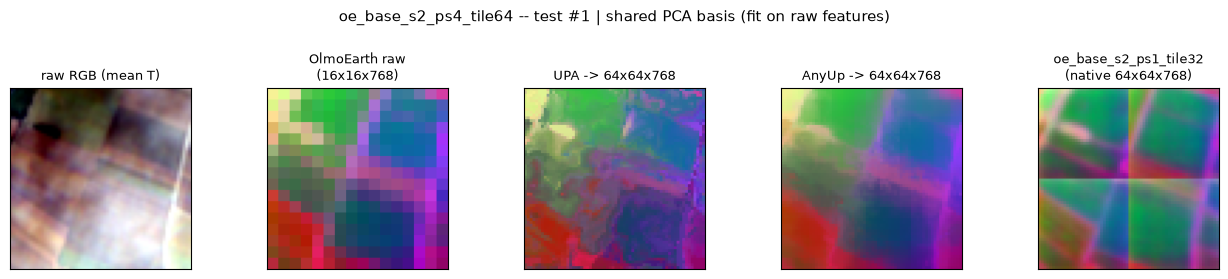

In [11]:
# ============================================================================
# Visualize ONE sample: raw OlmoEarth features (low-res) -> UPA upsampled ->
# pretrained AnyUp upsampled. Mirrors visualize_features.py's fig3_anyup, but
# adds the per-image-optimized UPA (defined in the cell above) as a middle method.
#
# Run from the repo root with the OlmoEarth env active (env_olmo.sh): AnyUp pulls
# torch.hub, UPA needs cuda. The cell above must have been executed (UPA,
# LearnablePixelwiseAnisoJBU_NoParent live there).
# ============================================================================
import sys, os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO = Path.cwd()                      # assume notebook launched from repo root
sys.path.insert(0, str(REPO / "olmo_shims"))
import olmo_bootstrap; olmo_bootstrap.apply()   # HDF5/rasterio ABI before olmoearth imports

# ---- config: which sample + which low-res feature dir to upsample ----
FEATURES_ROOT = Path("~/projects/aip-gpleiss/timz/features").expanduser()
LR_DIR   = "oe_base_s2_ps4_tile64"     # 16x16x768 grid -> scale 4 up to 64x64
REF_DIR  = "oe_base_s2_ps1_tile32"     # native 64x64x768, per-pixel reference (same D)
SPLIT    = "test"
IMG_IDX  = 1
DATA_SPLITS = REPO / "data" / "pastis_olmoearth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- PCA / raw-RGB helpers (copied from visualize_features.py so this cell is standalone) ----
RGB_BANDS = [3, 2, 1]
def raw_rgb(s2_t):
    rgb = s2_t[RGB_BANDS].float().numpy().transpose(1, 2, 0)
    lo, hi = np.percentile(rgb, 2, (0, 1)), np.percentile(rgb, 98, (0, 1))
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

def pca_rgb_shared(fit, apply_to):
    """Fit top-3 PCA + min-max on `fit` (H,W,D); apply that SAME basis to every map in
    `apply_to`. Shared basis => identical feature vectors get identical colors, so color
    differences across panels are real (not per-panel recoloring)."""
    Hf, Wf, D = fit.shape
    xf = fit.reshape(Hf * Wf, D).float().numpy()
    mean = xf.mean(0, keepdims=True)
    cov = ((xf - mean).T @ (xf - mean)) / max(Hf * Wf - 1, 1)
    _, evecs = np.linalg.eigh(cov)
    dirs = evecs[:, -3:][:, ::-1]
    proj_fit = (xf - mean) @ dirs
    lo, hi = proj_fit.min(0), proj_fit.max(0)
    out = []
    for m in apply_to:
        H, W, _ = m.shape
        x = m.reshape(H * W, D).float().numpy()
        proj = ((x - mean) @ dirs).reshape(H, W, 3)
        out.append(np.clip((proj - lo) / (hi - lo + 1e-6), 0, 1))
    return out

def nearest_resize(img, size=128):
    H, W = img.shape[:2]
    yi = (np.arange(size) * H // size).clip(0, H - 1)
    xi = (np.arange(size) * W // size).clip(0, W - 1)
    return img[yi][:, xi]

# ---- load the low-res OlmoEarth features + guidance for this one sample ----
lr = torch.load(FEATURES_ROOT / LR_DIR / f"pastis_r_{SPLIT}" / f"{IMG_IDX}.pt").float().mean(0)  # (gH,gW,D)
gH, gW, D = lr.shape
s2 = torch.load(DATA_SPLITS / f"pastis_r_{SPLIT}" / "s2_images" / f"{IMG_IDX}.pt")                # (T,13,64,64)
rgb_disp = raw_rgb(s2.mean(0))                                                                     # (64,64,3) in [0,1]
out_hw = (s2.shape[-2], s2.shape[-1])                                                              # (64,64)

# ============ method 1: raw low-res features (no upsampling) ============
lr_hw = lr                                                                                          # (gH,gW,D)

# ============ method 2: UPA (per-image optimized JBU, from the cell above) ============
# UPA(HR_img, lr_modality): HR_img is HxWx3 in 0..255 (it /255 internally); lr_modality is
# [1,C,Hl,Wl] on cuda. It fits the JBU to reconstruct RGB from its bicubic downsample, then
# applies the learned kernels to the feature map. scale = 64/gH is inferred inside.
hr_img_255 = (rgb_disp * 255).astype(np.uint8)                                                      # HxWx3 uint8
lr_feat_in = lr.permute(2, 0, 1).unsqueeze(0).to(device)                                            # (1,D,gH,gW)
upa_hr = UPA(hr_img_255, lr_feat_in)                                                                # (1,D,64,64)
upa_hw = upa_hr.squeeze(0).permute(1, 2, 0).float().cpu()                                           # (64,64,D)

# ============ method 3: pretrained AnyUp (torch.hub, frozen — no finetune_olmoearth_pastis import) ============
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
def _norm_rgb(rgb):
    flat = rgb.reshape(*rgb.shape[:-3], 3, -1)
    lo = flat.amin(-1).reshape(*rgb.shape[:-3], 3, 1, 1)
    hi = flat.amax(-1).reshape(*rgb.shape[:-3], 3, 1, 1)
    return ((rgb - lo) / (hi - lo + 1e-6) - _IMAGENET_MEAN) / _IMAGENET_STD

s2_full = torch.load(DATA_SPLITS / f"pastis_r_{SPLIT}" / "s2_images" / f"{IMG_IDX}.pt").float()
rgb_guide = _norm_rgb(s2_full.mean(0)[[3, 2, 1]])                                                   # (3,64,64)
anyup = torch.hub.load("wimmerth/anyup", "anyup_multi_backbone",
                       use_natten=False, pretrained=True).to(device).eval()
with torch.no_grad():
    anyup_hr = anyup(rgb_guide.unsqueeze(0).to(device),
                     lr.permute(2, 0, 1).unsqueeze(0).to(device),
                     output_size=out_hw)                                                            # (1,D,64,64)
anyup_hw = anyup_hr.squeeze(0).permute(1, 2, 0).float().cpu()                                       # (64,64,D)

# ============ optional native reference (ps1 tile64) ============
ref_hw = None
ref_path = FEATURES_ROOT / REF_DIR / f"pastis_r_{SPLIT}" / f"{IMG_IDX}.pt"
if ref_path.exists():
    cand = torch.load(ref_path).float().mean(0)                                                     # (64,64,D)
    if cand.shape[-1] == D:
        ref_hw = cand
    else:
        print(f"ref D={cand.shape[-1]} != {D}; skipping reference panel")

# ---- color every feature panel with ONE shared PCA basis (fit on the low-res map) so
#      lr / UPA / AnyUp / ref are directly comparable in color ----
maps = [lr_hw, upa_hw, anyup_hw] + ([ref_hw] if ref_hw is not None else [])
colored = pca_rgb_shared(lr_hw, maps)

panels = [rgb_disp] + [nearest_resize(c, 128) for c in colored]
titles = ["raw RGB (mean T)",
          f"OlmoEarth raw\n({gH}x{gW}x{D})",
          f"UPA -> 64x64x{D}",
          f"AnyUp -> 64x64x{D}"] + ([f"{REF_DIR}\n(native 64x64x{D})"] if ref_hw is not None else [])

fig, axes = plt.subplots(1, len(panels), figsize=(2.6 * len(panels), 2.8))
for ax, img, ttl in zip(axes, panels, titles):
    ax.imshow(img); ax.set_title(ttl, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{LR_DIR} -- test #{IMG_IDX} | shared PCA basis (fit on raw features)", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()
